1. Завантаження та підготовка даних

a. Викачати архів ml-latest-small.zip і розпакувати.

b. Завантажити таблиці ratings.csv і movies.csv за допомогою pandas.

c. Виконати об’єднання таблиць за полем movieId.

d. Для подальшого аналізу вибрати лише користувацькі оцінки rating ≥ 4.0, вважаючи, що це “фільми що сподобались користувачам”.

e. Вивести розміри таблиць та кількість унікальних користувачів і фільмів.

In [18]:
import pandas as pd
import numpy as np
import urllib.request
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

url = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
file_name = 'ml-latest-small.zip'

if not os.path.exists(file_name):
    urllib.request.urlretrieve(url, file_name)
    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall()

ratings = pd.read_csv('ml-latest-small/ratings.csv')
movies = pd.read_csv('ml-latest-small/movies.csv')

df = pd.merge(ratings, movies, on='movieId')

df_liked = df[df['rating'] >= 4.0]

print(f"Розмір вихідної таблиці ratings: {ratings.shape}")
print(f"Розмір відфільтрованої таблиці (rating >= 4.0): {df_liked.shape}")
print(f"Кількість унікальних користувачів: {df_liked['userId'].nunique()}")
print(f"Кількість унікальних фільмів, що сподобались: {df_liked['title'].nunique()}")

Розмір вихідної таблиці ratings: (100836, 4)
Розмір відфільтрованої таблиці (rating >= 4.0): (48580, 6)
Кількість унікальних користувачів: 609
Кількість унікальних фільмів, що сподобались: 6297


2. Перетворення даних у транзакційний формат

а. Створити матрицю (або DataFrame) у форматі:
 рядки — користувачі (userId),
 стовпці — фільми (title),
 значення — 1, якщо користувач поставив оцінку ≥ 4.0, і 0 інакше.
     
b. Вивести кілька перших рядків матриці для перевірки.

In [19]:
basket_sets = (basket > 0).astype(bool)

print("Перші 5 рядків та 5 стовпців транзакційної матриці:")
display(basket_sets.iloc[:5, :5])

Перші 5 рядків та 5 стовпців транзакційної матриці:


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)"
userId,,,,,
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
5,False,False,False,False,False


3. Пошук частих наборів фільмів

a. Використати алгоритм Apriori для пошуку частих наборів елементів.
    
b. Вивести кількість знайдених частих наборів при різних порогах min_support (наприклад, 0.05, 0.1, 0.3).
    
c. Відсортувати результати за значенням support і вивести топ-10 найпопулярніших комбінацій фільмів.

d.Інтерпретувати, які фільми часто зустрічаються разом у вподобаннях користувачів.

In [20]:
supports = [0.05, 0.1, 0.3]
print(f"Кількість знайдених наборів при")
for min_sup in supports:
    frequent_itemsets = apriori(basket_sets, min_support=min_sup, use_colnames=True)
    print(f" min_support = {min_sup}: {len(frequent_itemsets)}")

frequent_itemsets_final = apriori(basket_sets, min_support=0.1, use_colnames=True)

top_10_itemsets = frequent_itemsets_final.sort_values(by='support', ascending=False).head(10)
print("\nТоп-10 найпопулярніших комбінацій фільмів:")
display(top_10_itemsets)

Кількість знайдених наборів при
 min_support = 0.05: 33189
 min_support = 0.1: 863
 min_support = 0.3: 6

Топ-10 найпопулярніших комбінацій фільмів:


,support,itemsets
93,0.449918,"(Shawshank Redemption, The (1994))"
40,0.408867,(Forrest Gump (1994))
83,0.400657,(Pulp Fiction (1994))
96,0.369458,"(Silence of the Lambs, The (1991))"
68,0.364532,"(Matrix, The (1999))"
103,0.330049,(Star Wars: Episode IV - A New Hope (1977))
38,0.293924,(Fight Club (1999))
90,0.287356,(Schindler's List (1993))
279,0.275862,"(Shawshank Redemption, The (1994), Forrest Gum..."
104,0.275862,(Star Wars: Episode V - The Empire Strikes Bac...


4. Побудова асоціативних правил

a. Побудувати асоціативні правила.
    
b. Додати обчислення метрик support, confidence, lift.
    
c. Відсортувати та вивести топ-10 правил за lift.
    
d. Інтерпретувати кілька правил.
    
e. Візуалізувати розподіл метрик (графіки support–confidence, lift–confidence тощо).

Топ-10 асоціативних правил за метрикою Lift:


,antecedents,consequents,support,confidence,lift
490,(Kill Bill: Vol. 1 (2003)),(Kill Bill: Vol. 2 (2004)),0.106732,0.738636,6.247633
491,(Kill Bill: Vol. 2 (2004)),(Kill Bill: Vol. 1 (2003)),0.106732,0.902778,6.247633
2861,(Raiders of the Lost Ark (Indiana Jones and th...,"(Star Wars: Episode IV - A New Hope (1977), In...",0.106732,0.613208,4.668042
2860,"(Star Wars: Episode IV - A New Hope (1977), In...",(Raiders of the Lost Ark (Indiana Jones and th...,0.106732,0.812500,4.668042
1566,"(Goodfellas (1990), Godfather, The (1972))","(Godfather: Part II, The (1974))",0.100164,0.792208,4.508921
1567,"(Godfather: Part II, The (1974))","(Goodfellas (1990), Godfather, The (1972))",0.100164,0.570093,4.508921
2890,"(Matrix, The (1999), Lord of the Rings: The Tw...",(Lord of the Rings: The Fellowship of the Ring...,0.123153,0.882353,4.440933
2887,(Lord of the Rings: The Fellowship of the Ring...,"(Matrix, The (1999), Lord of the Rings: The Tw...",0.123153,0.619835,4.440933
2636,(Lord of the Rings: The Fellowship of the Ring...,"(Fight Club (1999), Lord of the Rings: The Two...",0.105090,0.528926,4.412544
2637,"(Fight Club (1999), Lord of the Rings: The Two...",(Lord of the Rings: The Fellowship of the Ring...,0.105090,0.876712,4.412544


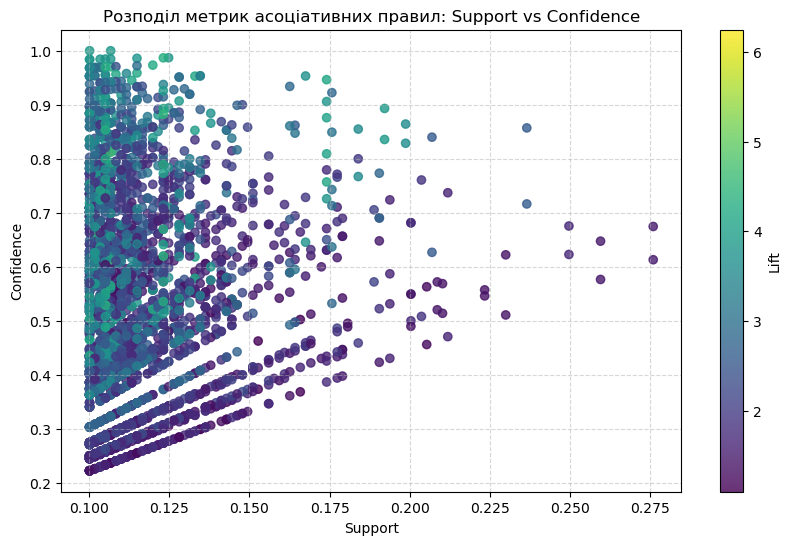

In [21]:
rules = association_rules(frequent_itemsets_final, metric="lift", min_threshold=1.0)

top_10_rules = rules.sort_values(by='lift', ascending=False).head(10)
print("Топ-10 асоціативних правил за метрикою Lift:")
display(top_10_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

plt.figure(figsize=(10, 6))
sc = plt.scatter(rules['support'], rules['confidence'], c=rules['lift'], cmap='viridis', alpha=0.8)
plt.colorbar(sc, label='Lift')
plt.title('Розподіл метрик асоціативних правил: Support vs Confidence')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()